In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("loan_approval_data (1).csv")

In [4]:
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
432,433.0,19749.0,3496.0,Contract,59.0,Single,2.0,776.0,1.0,0.55,1340.0,23377.0,26551.0,48.0,Home,Semiurban,Graduate,Female,NaN,No
108,NaN,16820.0,8407.0,Contract,46.0,Single,1.0,NaN,3.0,0.21,8123.0,8328.0,4679.0,60.0,Home,Urban,Graduate,Male,NaN,No
368,369.0,13922.0,3778.0,Salaried,40.0,Married,0.0,694.0,3.0,0.28,14439.0,40639.0,8549.0,24.0,Business,Rural,Not Graduate,Male,Private,Yes
642,643.0,5900.0,5238.0,Self-employed,34.0,Married,2.0,711.0,NaN,NaN,14691.0,43481.0,38834.0,84.0,Business,Semiurban,Graduate,Female,NaN,No
449,450.0,3062.0,6732.0,Salaried,56.0,NaN,0.0,732.0,2.0,0.55,11704.0,46104.0,16919.0,12.0,Home,Semiurban,Graduate,Female,Government,No
488,489.0,12150.0,7867.0,Contract,34.0,Married,2.0,588.0,4.0,0.21,NaN,40399.0,14919.0,36.0,Home,Urban,Not Graduate,Male,Unemployed,NaN
474,475.0,9494.0,9905.0,Contract,38.0,Single,NaN,724.0,3.0,0.20,17152.0,38108.0,8715.0,12.0,Education,Semiurban,Graduate,Male,Business,Yes
825,826.0,19334.0,2475.0,Salaried,43.0,NaN,3.0,687.0,1.0,0.53,5938.0,42244.0,16911.0,60.0,Business,Urban,Graduate,Female,MNC,No
886,887.0,3854.0,7574.0,Salaried,40.0,Married,3.0,588.0,NaN,0.28,13311.0,13731.0,12218.0,24.0,Home,Urban,Not Graduate,Male,Government,No
40,41.0,17787.0,3028.0,Contract,31.0,Single,2.0,661.0,1.0,0.32,NaN,5492.0,34706.0,48.0,Home,Urban,Graduate,Female,Business,Yes


In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.dropna()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
5,6.0,8265.0,4831.0,Salaried,53.0,Single,1.0,602.0,1.0,0.56,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
10,11.0,18023.0,4033.0,Salaried,52.0,Married,2.0,688.0,1.0,0.13,18244.0,40004.0,10415.0,12.0,Education,Urban,Not Graduate,Female,MNC,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,986.0,10705.0,7898.0,Salaried,33.0,Single,1.0,704.0,4.0,0.55,569.0,2654.0,11524.0,84.0,Home,Rural,Graduate,Female,Private,No
987,988.0,6841.0,2293.0,Self-employed,34.0,Married,2.0,639.0,2.0,0.22,2822.0,24204.0,27673.0,36.0,Car,Semiurban,Graduate,Male,Private,No
993,994.0,16596.0,6007.0,Self-employed,33.0,Married,2.0,688.0,4.0,0.21,1257.0,16206.0,35329.0,24.0,Home,Rural,Graduate,Male,Government,Yes
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No


In [7]:
df.shape

(1000, 20)

In [8]:
numerical_values = df.select_dtypes(include = ["float64"]).columns
catagorical_values = df.select_dtypes(include = ["object"]).columns

In [9]:
from sklearn.impute import SimpleImputer

In [10]:
num_imp = SimpleImputer(strategy = "mean")
df[numerical_values] = num_imp.fit_transform(df[numerical_values])

In [11]:
cat_imp = SimpleImputer(strategy = "most_frequent")
df[catagorical_values] = cat_imp.fit_transform(df[catagorical_values])

In [12]:
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
454,455.0,10924.0,89.0,Contract,21.000000,Single,3.000000,666.000000,0.000000,0.30,9940.452632,21034.000000,9015.000000,48.0,Car,Urban,Graduate,Female,Private,Yes
803,804.0,7984.0,1343.0,Salaried,31.000000,Married,1.474737,628.000000,1.950526,0.41,16528.000000,14246.000000,39976.000000,36.0,Car,Urban,Not Graduate,Female,Private,No
573,574.0,14338.0,6276.0,Salaried,39.000000,Single,2.000000,676.033684,1.000000,0.25,3367.000000,8851.000000,2902.000000,60.0,Home,Semiurban,Graduate,Female,MNC,Yes
624,625.0,8254.0,9110.0,Salaried,52.000000,Married,1.000000,566.000000,1.000000,0.23,6572.000000,24802.792632,26957.000000,12.0,Car,Semiurban,Graduate,Female,Private,No
458,459.0,8731.0,9078.0,Self-employed,29.000000,Single,1.000000,750.000000,2.000000,0.35,684.000000,20796.000000,20465.000000,12.0,Personal,Rural,Graduate,Female,Private,Yes
558,559.0,2404.0,9444.0,Salaried,56.000000,Married,1.000000,770.000000,1.950526,0.20,14838.000000,5913.000000,33596.000000,60.0,Personal,Urban,Not Graduate,Male,MNC,No
362,363.0,4479.0,1098.0,Unemployed,49.000000,Married,1.474737,627.000000,3.000000,0.31,9940.452632,25568.000000,21079.000000,60.0,Personal,Urban,Graduate,Female,Private,No
377,378.0,2851.0,933.0,Salaried,47.000000,Single,1.000000,715.000000,4.000000,0.38,9268.000000,35814.000000,13823.000000,84.0,Car,Urban,Graduate,Female,Unemployed,No
776,777.0,19988.0,3683.0,Salaried,39.971579,Married,1.000000,619.000000,3.000000,0.35,15226.000000,22829.000000,36904.000000,84.0,Education,Urban,Graduate,Male,Private,No
192,193.0,18371.0,8567.0,Salaried,50.000000,Married,1.000000,585.000000,0.000000,0.36,19466.000000,19346.000000,20522.825263,48.0,Education,Urban,Not Graduate,Female,Government,No


In [13]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

 # EDA

Text(0.5, 1.0, 'is loan approved or not')

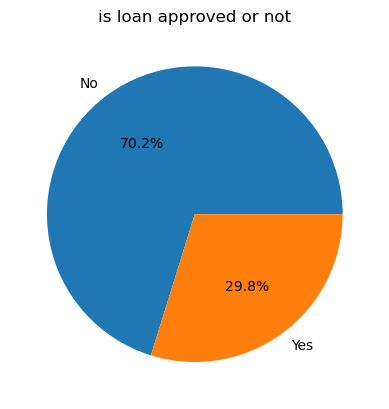

In [14]:
classes = df["Loan_Approved"].value_counts()
plt.pie(classes,labels = ["No","Yes"],autopct = "%1.1f%%")
plt.title("is loan approved or not")

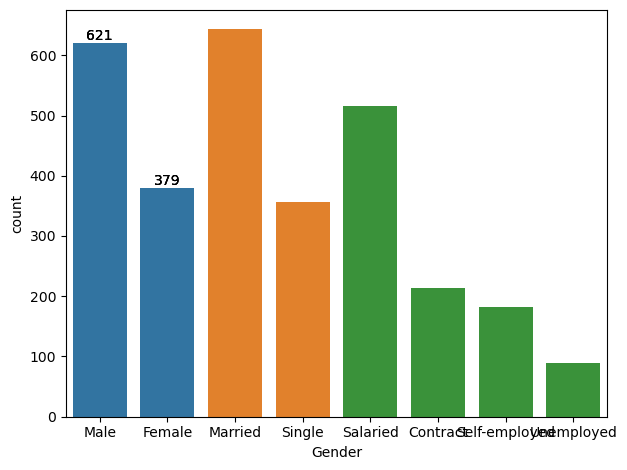

In [15]:
# analyaxe catoagories values

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

mar_cnt = df["Marital_Status"].value_counts()
ax = sns.barplot(mar_cnt)
ax.bar_label(ax.containers[0])

emp_cnt = df["Employment_Status"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

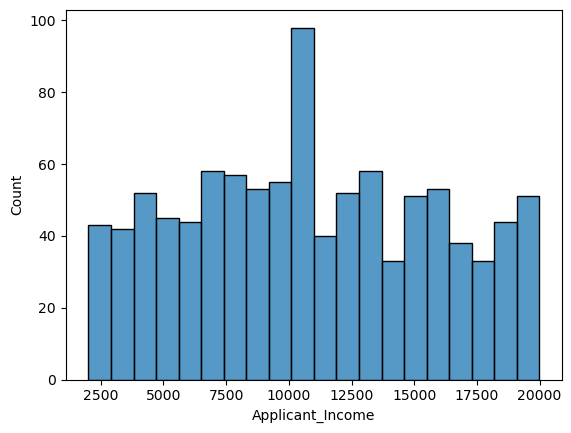

In [16]:
sns.histplot(data = df,x = "Applicant_Income",bins = 20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

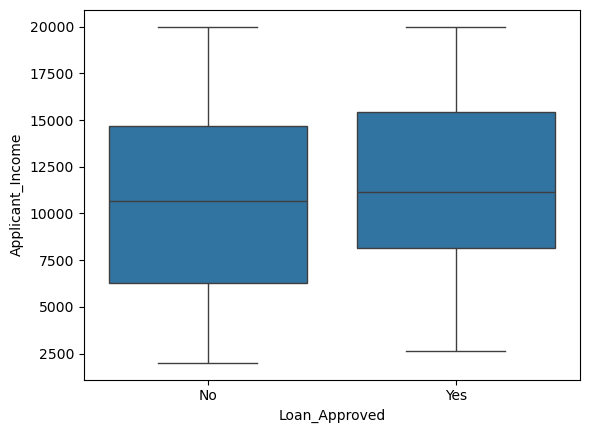

In [17]:
#  outliers = box plot

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

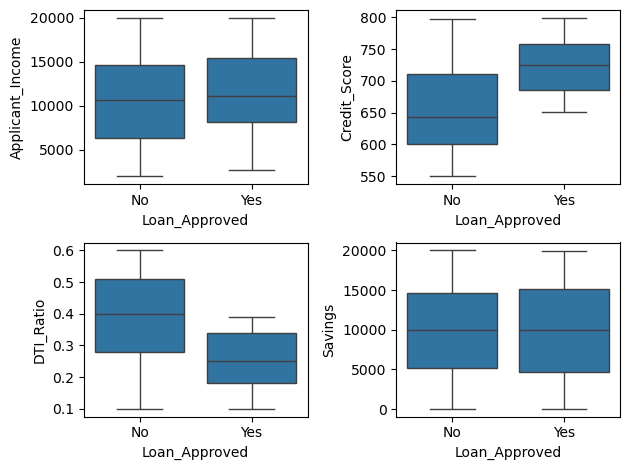

In [18]:
fig,axes = plt.subplots(2,2)

sns.boxplot(ax = axes[0,0],data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1],data = df,x = "Loan_Approved",y = "Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

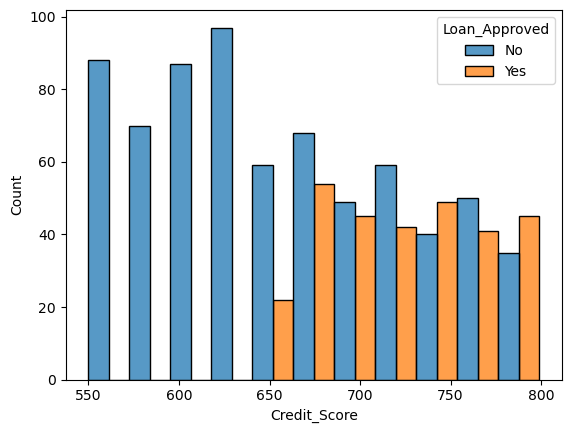

In [19]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    multiple = "dodge"
    
)

In [20]:
df = df.drop("Applicant_ID",axis = 1)

In [21]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df["Education_Level"] = le.fit_transform(df["Education_Level"])

In [24]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [25]:
#  one hot encoding 
from sklearn.preprocessing import OneHotEncoder

In [26]:
cols = ["Loan_Purpose","Property_Area","Marital_Status","Employment_Status","Gender","Employer_Category"]
on = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
encoded = on.fit_transform(df[cols])

In [27]:
encoded_df = pd.DataFrame(encoded , columns = on.get_feature_names_out(cols),index = df.index)

In [28]:
encoded_df.head()

,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [29]:
df = pd.concat([df.drop(columns = cols),encoded_df],axis = 1)

In [30]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [31]:
nums_col = df.select_dtypes(include="number")
corr_matrix = nums_col.corr()

<Axes: >

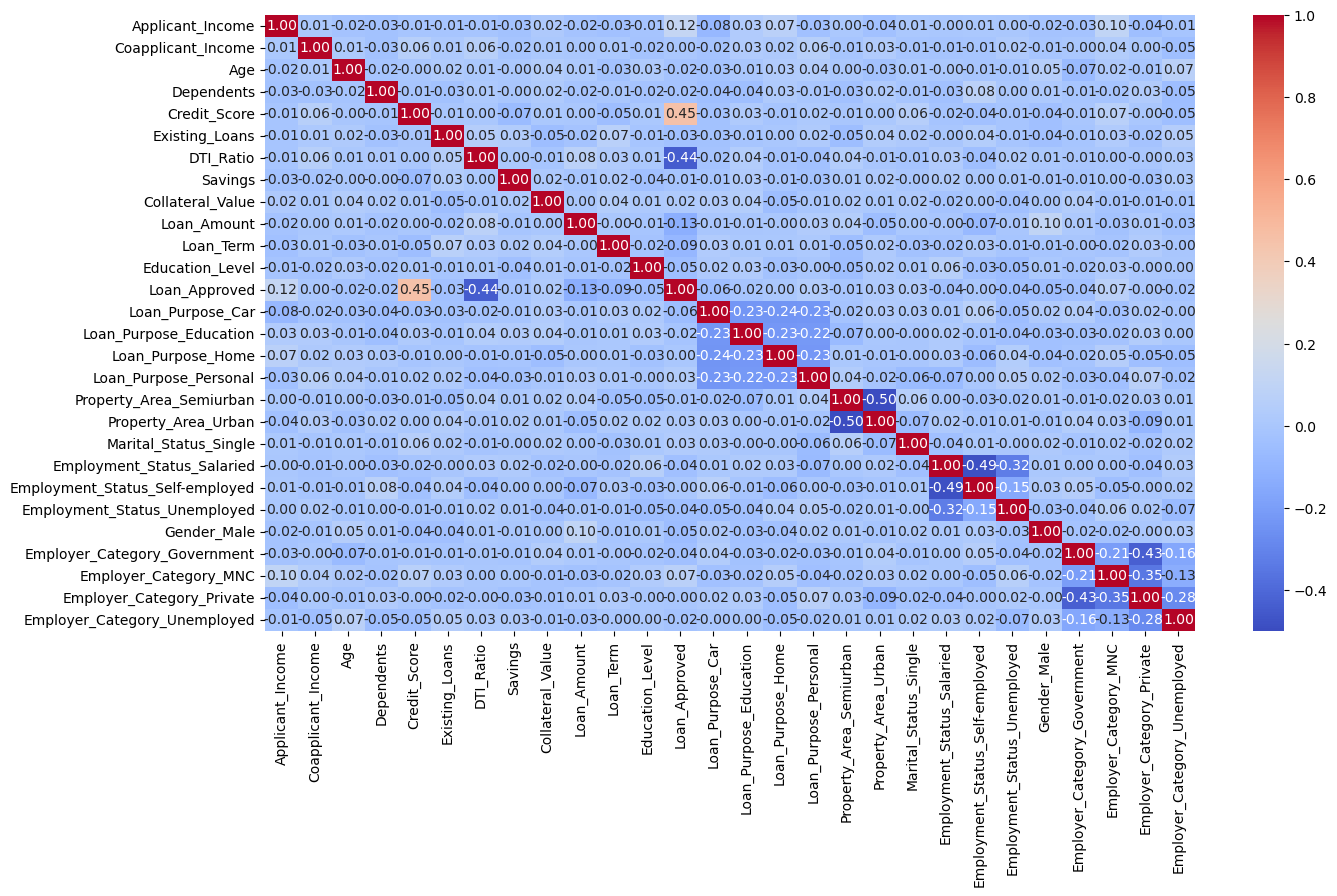

In [32]:
#  correlation heatmaps

plt.figure(figsize=(15,8))

sns.heatmap(
    corr_matrix,
    annot =True,
    fmt = "0.2f",
    cmap = "coolwarm"
)


In [33]:
#  feature scaling
x = df.drop("Loan_Approved",axis = 1)
y = df["Loan_Approved"]

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [38]:
#  evalutering and training the model

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression()

In [41]:
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [42]:
y_pred = model.predict(x_test_scaled)

In [43]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,f1_score,recall_score
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",accuracy_score(y_test,y_pred))

accuracy score:  0.865
precisionn score:  0.7833333333333333
recall score:  0.7704918032786885
confusion_matrix:  0.865


In [44]:
#  KNN

from sklearn.neighbors import KNeighborsClassifier

In [86]:
knn_model = KNeighborsClassifier(n_neighbors = 11)

In [87]:
knn_model.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=11)

In [88]:
y_pred = knn_model.predict(x_test_scaled)

In [89]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",confusion_matrix(y_test,y_pred))

accuracy score:  0.765
precisionn score:  0.675
recall score:  0.4426229508196721
confusion_matrix:  [[126  13]
 [ 34  27]]


In [49]:
#  neive bayes

from sklearn.naive_bayes import GaussianNB

In [50]:
nb_model = GaussianNB()
nb_model.fit(x_train_scaled,y_train)

GaussianNB()

In [51]:
y_pred = nb_model.predict(x_test_scaled)

In [52]:
print("accuracy score: ",accuracy_score(y_test,y_pred))
print("precisionn score: ",precision_score(y_test,y_pred))
print("recall score: ",recall_score(y_test,y_pred))
print("confusion_matrix: ",accuracy_score(y_test,y_pred))

accuracy score:  0.865
precisionn score:  0.8035714285714286
recall score:  0.7377049180327869
confusion_matrix:  0.865
